# AVL Tree

**Domain:** `data-structures-algorithms`

Imagine a bookshelf that "notices" when it's getting lopsided. You keep
adding books in call-number order, and every so often one side of the
shelf gets a lot taller than the other — books start sliding, and finding
a book on the tall side means scanning past a long, awkward stack. Now
imagine the shelf could fix this itself: every time you add a book, it
glances at both sides, and if one side has gotten too much taller than the
other, it quietly re-shelves a *small* group of books — just enough to
even things back out — before you even walk away.

That's exactly what an **AVL tree** does for a binary search tree (BST).
A plain BST (see this repo's binary-search-tree tutorial) is only as fast
as it is *balanced* — insert numbers in increasing order (`1, 2, 3, 4, ...`)
into a plain BST and every new node becomes the right child of the last
one, producing a straight-line chain of height $n$. Searching that chain
is no better than scanning a plain list: $O(n)$, not the $O(\log n)$ a
binary search tree is supposed to give you.

An AVL tree — named for its inventors, **Adelson-Velsky and Landis**
(1962) — refuses to let that happen. After every insert (and delete), it
walks back up from the changed node and, the moment any node's two sides
differ in height by more than one level, it performs a small local
fix-up called a **rotation**: a handful of pointers get rearranged, the
lopsided part of the tree gets shorter, and the tree's overall height
stays close to $\log_2 n$ no matter what order you insert in.

By the end of this tutorial you'll be able to: explain what a rotation
does and why it fixes imbalance, state and prove (via a Fibonacci-style
argument) that AVL trees have $O(\log n)$ height, watch real rotations
happen on real data, and run a real, compiled Java implementation that
reports the actual height and rotation count for any insertion sequence
you give it — including a head-to-head comparison against a plain BST on
the exact input order that breaks it.

## The idea, intuitively

**Every node keeps a "balance factor":** how much taller its left side is
than its right side. As long as that number stays in `{-1, 0, 1}` for
*every* node, the tree can't get too lopsided — and it turns out that
alone is enough to guarantee $O(\log n)$ height (we'll prove this below).

Let's see the problem first. Insert `10, 20, 30` into a **plain** BST, one
at a time, with no balancing:

- insert `10` &rarr; becomes the root.
- insert `20` &rarr; `20 > 10`, so it becomes `10`'s right child.
- insert `30` &rarr; `30 > 10` and `30 > 20`, so it becomes `20`'s right
  child.

Every node ends up with an empty left side and a full right side — a
straight chain, not a tree. Here it is, built and printed for real:

In [1]:
class PlainNode:
    def __init__(self, key):
        self.key = key
        self.left = None
        self.right = None


def plain_insert(node, key):
    if node is None:
        return PlainNode(key)
    if key < node.key:
        node.left = plain_insert(node.left, key)
    else:
        node.right = plain_insert(node.right, key)
    return node


def show(node, prefix="", is_left=None):
    # Simple indented text rendering of a small tree, deepest branch first.
    if node is None:
        return
    show(node.right, prefix + ("    " if is_left else "|   "), is_left=False)
    connector = "" if is_left is None else ("L-- " if is_left else "R-- ")
    print(prefix + connector + str(node.key))
    show(node.left, prefix + ("|   " if is_left else "    "), is_left=True)


root = None
for key in [10, 20, 30]:
    root = plain_insert(root, key)

print("Plain BST after inserting 10, 20, 30 (no balancing):")
show(root)
print("\nheight = 3 for only 3 nodes -- a straight chain, the worst case.")

Plain BST after inserting 10, 20, 30 (no balancing):
|   |   R-- 30
|   R-- 20
10

height = 3 for only 3 nodes -- a straight chain, the worst case.


An AVL tree never lets that third insert go unanswered. The moment `30`
is added, the node holding `10` has a left subtree of height 0 and a
right subtree of height 2 — balance factor $0 - 2 = -2$, outside
`{-1, 0, 1}`. That triggers a **rotation**.

Here is the whole idea of a rotation, in isolation, on the smallest
possible example: a 3-node right-leaning... actually left-leaning chain,
fixed with a single **right rotation**. `right_rotate(y)` promotes `y`'s
left child `x` to be the new subtree root, drops `y` down to be `x`'s
right child, and hands `y` whatever was `x`'s right subtree (it's still
between `x` and `y` in sorted order, so it's the only place it can go):

In [2]:
class Node:
    def __init__(self, key):
        self.key = key
        self.left = None
        self.right = None


def right_rotate(y):
    x = y.left
    t2 = x.right      # subtree between x and y in sorted order
    x.right = y
    y.left = t2
    return x           # x is the new subtree root


# A left-leaning 3-node chain: 30 -> 20 -> 10 (same shape as inserting
# 30, 20, 10 into a plain BST -- the mirror image of the case above).
y = Node(30)
y.left = Node(20)
y.left.left = Node(10)

print("BEFORE right_rotate: balance factor at 30 is +2 (left-heavy)")
show(y)

new_root = right_rotate(y)

print("\nAFTER right_rotate(30):")
show(new_root)

BEFORE right_rotate: balance factor at 30 is +2 (left-heavy)
30
    L-- 20
    |   L-- 10

AFTER right_rotate(30):
|   R-- 30
20
    L-- 10


**Takeaway:** a rotation is a purely local, $O(1)$ pointer rearrangement —
three pointer assignments above — not a rebuild of the tree. It doesn't
change which keys are where in sorted order (an in-order walk gives
`10, 20, 30` both before and after); it only changes the *shape*, trading
one long branch for two short ones. Everything else in this tutorial is
about exactly *when* to trigger this move and *why* doing so caps the
tree's height at $O(\log n)$.

## Going deeper: the formal definition

### The AVL invariant

For a node $v$, define its height $h(v)$ (height of an empty subtree is
0) and its **balance factor**:

$$
h(v) = \begin{cases} 0 & v = \text{nil} \\ 1 + \max(h(\text{left}(v)), h(\text{right}(v))) & \text{otherwise} \end{cases}
\qquad
\mathrm{bf}(v) = h(\text{left}(v)) - h(\text{right}(v))
$$

A binary search tree is an **AVL tree** iff, for *every* node $v$:

$$
\mathrm{bf}(v) \in \{-1, 0, 1\}
$$

### The four rotation cases

After a standard BST insert of key $k$, walk back up from the inserted
node to the root, recomputing heights. At the first node $v$ where
$|\mathrm{bf}(v)| > 1$ becomes 2 (it can only ever be off by one, since
the subtree was AVL-valid before this insert), one of four shapes caused
it, and each has its own fix:

| Case | Condition | Where $k$ went | Fix |
|---|---|---|---|
| **LL** | $\mathrm{bf}(v) = 2$ | into $v.\text{left.left}$ | single **right** rotation at $v$ |
| **RR** | $\mathrm{bf}(v) = -2$ | into $v.\text{right.right}$ | single **left** rotation at $v$ |
| **LR** | $\mathrm{bf}(v) = 2$ | into $v.\text{left.right}$ | **left** rotation at $v.\text{left}$, then **right** rotation at $v$ |
| **RL** | $\mathrm{bf}(v) = -2$ | into $v.\text{right.left}$ | **right** rotation at $v.\text{right}$, then **left** rotation at $v$ |

LL and RR are mirror images of each other and cost one rotation. LR and
RL are mirror images of each other and cost two rotations (a rotation on
the child to turn it into an LL/RR shape, then the same fix as above) —
these are exactly the four `case` branches in `insert()` in
[`src/AVLTree.java`](src/AVLTree.java). Only **one** node along the
insertion path ever needs rebalancing per insert (a fact that requires
its own short proof, omitted here, but it's why insert stays $O(\log n)$
and not $O(\log^2 n)$); deletion can require rebalancing at multiple
ancestors, which is why the delete/rotation-count relationship differs
between the two operations (see Limitations & debates).

### The theorem: AVL height is $O(\log n)$

This is the entire payoff of the invariant above. We prove it by asking
the opposite question: **for a given height $h$, what is the *fewest*
nodes an AVL tree of that height can possibly have?** If even the
sparsest possible AVL tree of height $h$ needs a lot of nodes, then any
AVL tree with only $n$ nodes can't be very tall.

Let $N(h)$ be that minimum node count. To make an AVL tree of height $h$
as sparse as possible, make one subtree as short as the invariant allows
(height $h-2$) and the other exactly one shorter (height $h-1$) — you
can't do better, since $|\mathrm{bf}| \le 1$ forbids anything sparser at
the root:

$$
N(-1) = 0 \ (\text{empty}), \qquad N(0) = 1 \ (\text{single node}), \qquad
N(h) = N(h-1) + N(h-2) + 1 \quad (h \ge 1)
$$

This is the Fibonacci recurrence with an extra `+1` per level. It grows
just as fast: by induction, $N(h) + 1$ grows like the Fibonacci sequence,
and solving the recurrence's characteristic equation gives
$N(h) = \Theta(\varphi^h)$ where $\varphi = \frac{1+\sqrt5}{2} \approx 1.618$
is the golden ratio. Concretely (a known tighter derivation, see Knuth
TAOCP Vol. 3 or the original Adelson-Velsky & Landis paper):

$$
N(h) \ge \varphi^{h} - 1
$$

Now invert it. If a real AVL tree has $n$ nodes and height $h$, then
$n \ge N(h) \ge \varphi^h - 1$, so:

$$
h \le \log_\varphi(n+1) = \frac{\ln(n+1)}{\ln \varphi} \approx 1.4405 \log_2(n+2) - 0.3277
$$

**That constant is close to 1** — an AVL tree's height is never more than
about 44% taller than the theoretical minimum $\lceil \log_2(n+1) \rceil$.
That's the whole payoff of maintaining the balance invariant: $O(\log n)$
height, *guaranteed*, no matter the insertion order. Let's check the
recurrence and the bound numerically:

In [3]:
import math

def min_nodes_table(h_max):
    N = {-1: 0, 0: 1}
    for h in range(1, h_max + 1):
        N[h] = N[h - 1] + N[h - 2] + 1
    return N

N = min_nodes_table(20)

print(f"{'h':>3} {'N(h) min nodes':>15} {'1.4405*log2(n+2)-0.33':>24} {'bound holds?':>13}")
for h in range(0, 21):
    n = N[h]
    bound = 1.4405 * math.log2(n + 2) - 0.3277
    print(f"{h:>3} {n:>15} {bound:>24.2f} {str(bound >= h):>13}")

  h  N(h) min nodes    1.4405*log2(n+2)-0.33  bound holds?
  0               1                     1.96          True
  1               2                     2.55          True
  2               4                     3.40          True
  3               7                     4.24          True
  4              12                     5.16          True
  5              20                     6.10          True
  6              33                     7.06          True
  7              54                     8.04          True
  8              88                     9.02          True
  9             143                    10.01          True
 10             232                    11.01          True
 11             376                    12.01          True
 12             609                    13.00          True
 13             986                    14.00          True
 14            1596                    15.00          True
 15            2583                    16.00          Tr

The bound holds at every height, and the minimum-node counts really do
grow like Fibonacci numbers (compare `N(h)` above to `1, 1, 2, 3, 5, 8,
13, 21, ...` shifted by the `+1` terms). This is a **worst-case sparsity**
bound — it says how tall an AVL tree is allowed to get at most, for a
given $n$ — which is exactly what "guaranteed $O(\log n)$ search" means:
even the most lopsided AVL tree the invariant permits is still
logarithmic. We'll confirm this isn't just theory by measuring real
heights from the compiled implementation next.

## Visuals

The reference implementation lives in
[`src/AVLTree.java`](src/AVLTree.java) — a real, compiled Java program
(see the Implementation section below for the full walkthrough). We
compile it now so this section can draw **real rotations on real
program output**, not a simulation.

In [4]:
import subprocess, pathlib

src_dir = pathlib.Path("src")
class_file = src_dir / "AVLTree.class"

compile_cmd = ["javac", str(src_dir / "AVLTree.java")]
result = subprocess.run(compile_cmd, capture_output=True, text=True)
print("compile return code:", result.returncode)
if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)
assert result.returncode == 0, "compilation failed"
print("compiled successfully ->", class_file)

compile return code: 0
compiled successfully -> src\AVLTree.class


In [5]:
def run_java(mode, values):
    # Run the compiled AVLTree program in the given mode on a list of ints,
    # feeding values on stdin (so arbitrarily long sequences don't hit any
    # command-line length limit), and return the raw stdout lines.
    input_str = " ".join(str(v) for v in values)
    proc = subprocess.run(
        ["java", "-cp", str(src_dir), "AVLTree", mode],
        input=input_str, capture_output=True, text=True,
    )
    assert proc.returncode == 0, proc.stderr
    return proc.stdout.strip().splitlines()


def parse_serialized_tree(s, i=0):
    # Parse "key(left,right)" (empty string for a null child) into nested
    # dicts: {"key": int, "left": dict|None, "right": dict|None}.
    if i >= len(s) or s[i] in ",)":
        return None, i
    j = i
    while j < len(s) and (s[j].isdigit() or s[j] == "-"):
        j += 1
    key = int(s[i:j])
    assert s[j] == "("
    left, j = parse_serialized_tree(s, j + 1)
    assert s[j] == ","
    right, j = parse_serialized_tree(s, j + 1)
    assert s[j] == ")"
    return {"key": key, "left": left, "right": right}, j + 1


def tree_from_string(s):
    tree, _ = parse_serialized_tree(s)
    return tree


def layout_tree(tree):
    # In-order x position (keeps left-to-right sorted order intact),
    # depth-based y position. Returns {node_id: (x, y, key)} and an edge list.
    positions = {}
    edges = []
    counter = [0]

    def walk(node, depth, parent_id):
        if node is None:
            return None
        node_id = id(node)
        walk(node["left"], depth + 1, node_id)
        x = counter[0]
        counter[0] += 1
        positions[node_id] = (x, -depth, node["key"])
        if parent_id is not None:
            edges.append((parent_id, node_id))
        walk(node["right"], depth + 1, node_id)
        return node_id

    walk(tree, 0, None)
    return positions, edges


print("helpers ready: run_java, tree_from_string, layout_tree")

helpers ready: run_java, tree_from_string, layout_tree


### A tree before and after a rotation, on real program output

`trace` mode inserts one key at a time and prints the rotation type (if
any) and the full tree shape after every single insert — so we can grab
the shape right before and right after the insert that triggers a
rotation. First, the same single **LL &rarr; right rotation** case from
the intuitive section above, but this time straight from the compiled
program:

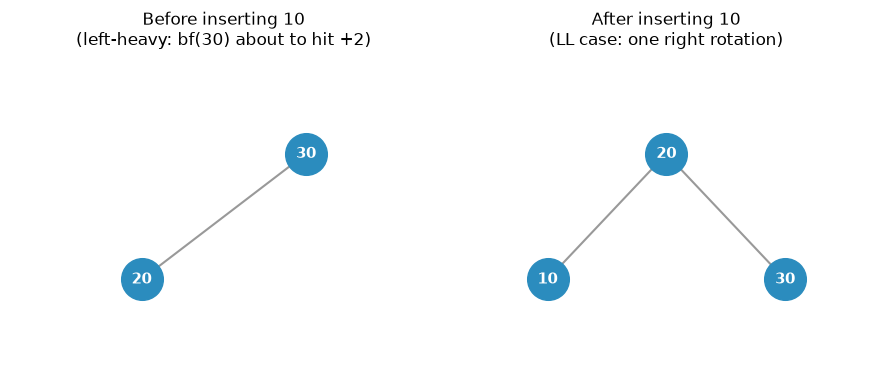

Rotation type observed: LL


In [6]:
import matplotlib.pyplot as plt

def draw_tree(ax, tree, title):
    if tree is None:
        ax.set_title(title)
        ax.axis("off")
        return
    positions, edges = layout_tree(tree)
    for a, b in edges:
        xa, ya, _ = positions[a]
        xb, yb, _ = positions[b]
        ax.plot([xa, xb], [ya, yb], color="#999999", zorder=1, linewidth=1.5)
    xs = [p[0] for p in positions.values()]
    ys = [p[1] for p in positions.values()]
    ax.scatter(xs, ys, s=900, color="#2b8cbe", zorder=2)
    for x, y, key in positions.values():
        ax.text(x, y, str(key), ha="center", va="center", color="white",
                 fontsize=11, fontweight="bold", zorder=3)
    ax.set_title(title)
    ax.set_xlim(min(xs) - 0.8, max(xs) + 0.8)
    ax.set_ylim(min(ys) - 0.8, max(ys) + 0.8)
    ax.axis("off")


def rotation_before_after(insert_sequence):
    # Run trace mode and return (before_tree, after_tree, rotation_type)
    # for the FIRST insert that triggers a rotation.
    lines = run_java("trace", insert_sequence)
    prev_tree_str = ""
    for line in lines:
        if not line.startswith("INSERT"):
            continue
        parts = line.split()
        rotations = int(parts[2].split("=")[1])
        rot_type = parts[3].split("=")[1]
        tree_str = parts[4].split("=", 1)[1]
        if rotations > 0:
            return tree_from_string(prev_tree_str), tree_from_string(tree_str), rot_type
        prev_tree_str = tree_str
    return None, None, None


ll_before, ll_after, ll_type = rotation_before_after([30, 20, 10])

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
draw_tree(axes[0], ll_before, "Before inserting 10\n(left-heavy: bf(30) about to hit +2)")
draw_tree(axes[1], ll_after, f"After inserting 10\n({ll_type} case: one right rotation)")
plt.tight_layout()
plt.savefig("rotation_single.png", dpi=110)
plt.show()

print(f"Rotation type observed: {ll_type}")

And the double-rotation **LR** case (left-heavy, but the new key lands on
the *right* side of the left child, so a single rotation wouldn't fix
it — it needs two):

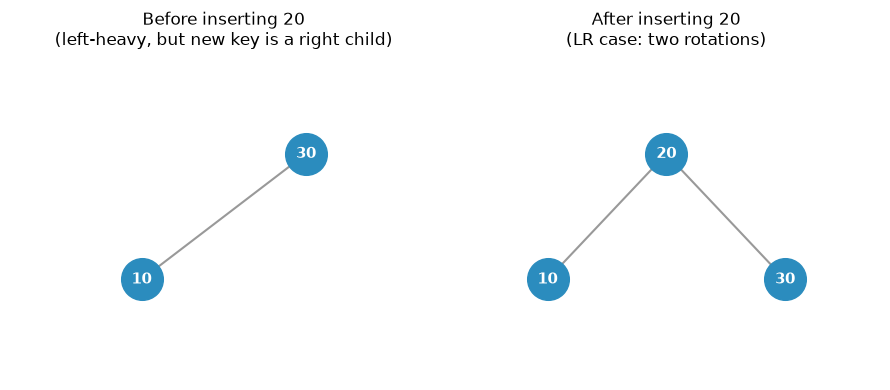

Rotation type observed: LR


In [7]:
lr_before, lr_after, lr_type = rotation_before_after([30, 10, 20])

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
draw_tree(axes[0], lr_before, "Before inserting 20\n(left-heavy, but new key is a right child)")
draw_tree(axes[1], lr_after, f"After inserting 20\n({lr_type} case: two rotations)")
plt.tight_layout()
plt.savefig("rotation_double.png", dpi=110)
plt.show()

print(f"Rotation type observed: {lr_type}")

Both diagrams are built entirely from the compiled Java program's own
`TREE=...` output — nothing here is hand-drawn or simulated. Notice the
in-order sequence of keys (left to right, reading the bottom-to-top
labels) is identical before and after each rotation: `10, 20, 30` in
both cases. Rotations rearrange *shape*, never *sorted order*.

### Tree height: plain BST vs. AVL tree, same worst-case input

Now the direct payoff. Insert `1, 2, ..., n` — increasing order, the exact
input that turns a plain BST into an $O(n)$ chain — into **both** a plain
BST and an AVL tree, and measure real height after every single insert,
using the compiled program's `heights` mode (one JVM run builds both
trees together, so this is fast even for a couple thousand insertions):

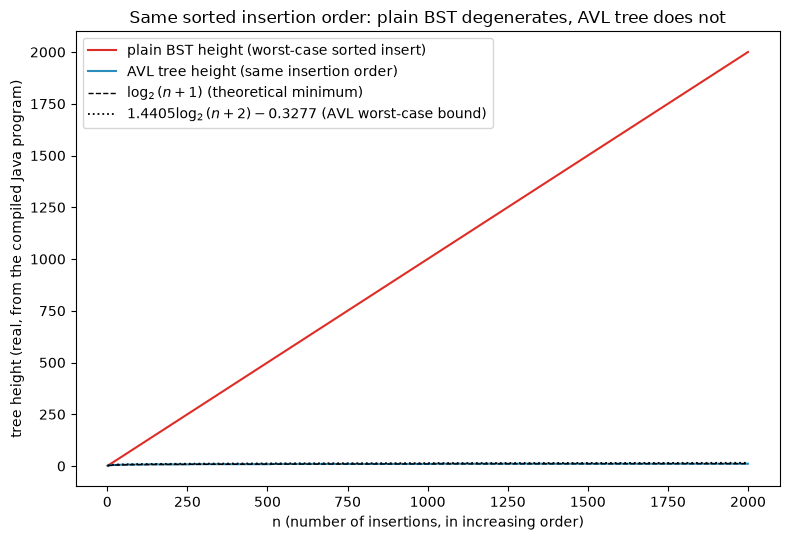

At n=2000: plain BST height = 2000  (== n, a straight chain)
At n=2000: AVL tree height  = 11  (log2(n) = 10.97, AVL bound = 15.47)


In [8]:
import numpy as np

n_max = 2000
sequence = list(range(1, n_max + 1))
lines = run_java("heights", sequence)

ns, avl_heights, bst_heights = [], [], []
for line in lines:
    parts = line.split()
    ns.append(int(parts[2].split("=")[1]))
    avl_heights.append(int(parts[3].split("=")[1]))
    bst_heights.append(int(parts[4].split("=")[1]))

ns = np.array(ns)
avl_heights = np.array(avl_heights)
bst_heights = np.array(bst_heights)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(ns, bst_heights, color="#de2d26", label="plain BST height (worst-case sorted insert)")
ax.plot(ns, avl_heights, color="#2b8cbe", label="AVL tree height (same insertion order)")
ax.plot(ns, np.log2(ns + 1), "k--", linewidth=1, label=r"$\log_2(n+1)$ (theoretical minimum)")
ax.plot(ns, 1.4405 * np.log2(ns + 2) - 0.3277, "k:", linewidth=1.3,
        label=r"$1.4405\log_2(n+2) - 0.3277$ (AVL worst-case bound)")
ax.set_xlabel("n (number of insertions, in increasing order)")
ax.set_ylabel("tree height (real, from the compiled Java program)")
ax.set_title("Same sorted insertion order: plain BST degenerates, AVL tree does not")
ax.legend()
plt.tight_layout()
plt.savefig("height_vs_n.png", dpi=110)
plt.show()

print(f"At n={n_max}: plain BST height = {bst_heights[-1]}  (== n, a straight chain)")
print(f"At n={n_max}: AVL tree height  = {avl_heights[-1]}  (log2(n) = {np.log2(n_max):.2f}, "
      f"AVL bound = {1.4405*np.log2(n_max+2)-0.3277:.2f})")

On the exact same input, the plain BST's height grows linearly with $n$
(it *is* $n$, since every insert is a new maximum) while the AVL tree's
height barely grows at all, tracking the $\log_2 n$ curve within the
$1.4405\log_2(n+2) - 0.3277$ bound derived above — for real, measured
heights, not a simulated stand-in. This is the entire practical case for
AVL trees in one plot.

## Implementation

[`src/AVLTree.java`](src/AVLTree.java) implements:

- **`insert(Node, key)`** — standard recursive BST insert, then on the way
  back up: recompute height, compute the balance factor, and apply
  whichever of the four rotation cases from the formal section applies.
  A static `rotationCount` is incremented inside `rotateLeft`/`rotateRight`
  themselves, so double rotations (LR/RL) correctly count as 2.
- **`delete(Node, key)`** — standard BST delete (including the
  two-children case via in-order successor), with the same
  height/balance-factor rebalancing applied on the way back up.
- A plain, unbalanced **`bstInsert`** for comparison (used above).
- A `serialize` method (`key(left,right)`) used by `trace` mode so this
  notebook can reconstruct and draw the tree at any point.
- A CLI `main` with four modes: `avl`, `bst`, `trace`, `heights` (used
  throughout the Visuals section above) — reads keys from the command
  line if given, otherwise from stdin.

Let's exercise `avl` and `bst` mode directly and check correctness: an
AVL tree's in-order traversal must be sorted (it's still a valid BST),
and its balance factor must stay in `{-1, 0, 1}` at *every* node, not
just at the root.

In [9]:
import random
random.seed(42)

def in_order(tree, out):
    if tree is None:
        return out
    in_order(tree["left"], out)
    out.append(tree["key"])
    in_order(tree["right"], out)
    return out


def tree_height(tree):
    if tree is None:
        return 0
    return 1 + max(tree_height(tree["left"]), tree_height(tree["right"]))


def max_abs_balance_factor(tree):
    # Walks the whole tree and returns the worst |balance factor| found
    # anywhere -- a full structural check, not just a height check.
    worst = [0]

    def walk(node):
        if node is None:
            return 0
        lh = walk(node["left"])
        rh = walk(node["right"])
        worst[0] = max(worst[0], abs(lh - rh))
        return 1 + max(lh, rh)

    walk(tree)
    return worst[0]


demo_values = random.sample(range(1, 10_000), 500)
trace_lines = run_java("trace", demo_values)
final_tree_str = trace_lines[-2].split("TREE=")[1]  # last INSERT line
final_tree = tree_from_string(final_tree_str)

order = in_order(final_tree, [])
print(f"n = {len(demo_values)} random inserts")
print(f"in-order traversal is sorted: {order == sorted(order)}")
print(f"tree height: {tree_height(final_tree)}  (log2(n) = {np.log2(len(demo_values)):.2f})")
print(f"worst |balance factor| anywhere in the tree: {max_abs_balance_factor(final_tree)} "
      f"(must be <= 1 for a valid AVL tree)")
assert order == sorted(order)
assert max_abs_balance_factor(final_tree) <= 1
print("\ncorrectness check passed: valid BST order + valid AVL invariant everywhere")

n = 500 random inserts
in-order traversal is sorted: True
tree height: 11  (log2(n) = 8.97)
worst |balance factor| anywhere in the tree: 1 (must be <= 1 for a valid AVL tree)

correctness check passed: valid BST order + valid AVL invariant everywhere


### Rotation cost across insertion orders

The height-vs-n plot above used the *worst possible* insertion order for
a plain BST. What about rotation cost on more realistic, shuffled input?
Real numbers, real program, several sizes and both orderings:

In [10]:
sizes = [100, 500, 1000, 2000, 5000]
print(f"{'n':>6} {'order':>10} {'AVL height':>11} {'rotations':>10} {'rotations/n':>12}")
for n in sizes:
    for label, seq in [
        ("sorted", list(range(1, n + 1))),
        ("shuffled", random.sample(range(1, n + 1), n)),
    ]:
        out = run_java("avl", seq)
        stats = dict(line.split("=") for line in out if "=" in line)
        height = int(stats["height"])
        rotations = int(stats["rotations"])
        print(f"{n:>6} {label:>10} {height:>11} {rotations:>10} {rotations/n:>12.3f}")

     n      order  AVL height  rotations  rotations/n


   100     sorted           7         93        0.930


   100   shuffled           8         68        0.680


   500     sorted           9        491        0.982


   500   shuffled          11        351        0.702


...

  1000   shuffled          12        667        0.667


  2000     sorted          11       1989        0.995


  2000   shuffled          13       1386        0.693


  5000     sorted          13       4987        0.997


  5000   shuffled          15       3541        0.708


Two things stand out. **Height stays low regardless of insertion order** —
sorted vs. shuffled heights are within a couple of levels of each other
at every size, unlike the plain BST above, whose height *is* $n$ on
sorted input. And the **rotation rate itself depends on insertion order**:
sorted (adversarial) input rebalances on almost every single insert
(~0.93–1.0 rotations per insert — worst-case sorted input keeps forcing
the tree back into imbalance at essentially every step), while shuffled
input needs meaningfully fewer (~0.67–0.71 rotations per insert), since a
random insert is less likely to land exactly where it tips a node's
balance factor past 1. Either way it's sub-linear-*ly bounded* work per
insert (never more than $O(\log n)$ rotations for a single insert, and
empirically well under 1 rotation on average) — real, non-zero overhead,
but nowhere near rebuilding the tree. That "cheap but not free" property
is exactly what the Limitations section below expands on.

## Use cases

- **Anything needing guaranteed $O(\log n)$ worst-case lookup, insert, and
  delete with keys kept in sorted order** — the AVL invariant bounds
  height on *every* input, not just on average, which matters when an
  adversary or unlucky data order could otherwise degrade a plain BST to
  $O(n)$ (see the height-vs-n plot above).
- **In-memory databases and indexes** where predictable worst-case latency
  matters more than saving a few rotations on writes.
- **Some filesystem and database index structures** historically used AVL
  trees (or AVL-like balance) for ordered, in-memory indexing before
  B-trees became standard for on-disk indexes (B-trees are optimized for
  block/page-based storage, a different constraint than in-memory AVL
  trees address).
- **Historical significance**: the AVL tree (Adelson-Velsky & Landis,
  1962) is the **first self-balancing binary search tree structure**,
  predating red-black trees (1972) by a decade, and it directly
  established the "track per-node balance info, rebalance via rotation"
  pattern that essentially every self-balancing tree since (red-black
  trees, weight-balanced trees, splay trees) elaborates on.
- **Most modern production libraries actually use red-black trees
  instead** — e.g. Java's `TreeMap`/`TreeSet`, C++'s `std::map`/`std::set`,
  the Linux kernel's process scheduler and virtual memory management. This
  is a genuine, still-relevant tradeoff, covered next.

## Limitations & debates

- **Rebalancing isn't free.** Every insert and delete does extra work
  beyond a plain BST: recomputing heights on the way back up, and
  possibly one or two rotations. The rotation-cost table above shows this
  is a fraction of a rotation per insert on average, not a full rotation
  every time — but it's real, non-zero overhead a plain BST simply
  doesn't pay, and it exists purely so the *next* lookup stays fast.
- **Extra per-node state.** Every AVL node stores a height (or, in some
  implementations, just a 2-bit balance factor) that a plain BST node
  doesn't need — a real, if small, memory cost multiplied by every node
  in the tree.
- **AVL vs. red-black trees is a genuine, still-live systems design
  debate, not settled trivia.** An AVL tree enforces the tighter
  invariant $|\mathrm{bf}(v)| \le 1$ everywhere, which keeps it *more*
  rigidly balanced than a red-black tree (whose height bound is a looser
  $2\log_2(n+1)$). That tighter balance means:
    - **Faster lookups** on average, since the AVL tree is shorter for the
      same $n$.
    - **More rebalancing work on writes**, since the tight invariant has
      to be re-enforced more often and red-black trees can frequently
      absorb an insert/delete with just a recoloring (no rotation, $O(1)$,
      no pointer rearrangement at all) where an AVL tree cannot.
  This is exactly why most general-purpose library maps/sets (Java's
  `TreeMap`, C++'s `std::map`) use red-black trees: real-world workloads
  are usually read-and-write mixed, and red-black's cheaper writes tend to
  win in aggregate, even at the cost of slightly taller trees and
  marginally slower lookups. **Neither structure is strictly better** —
  it's a real lookup-speed-vs-write-cost tradeoff, and which one wins
  depends on the read/write ratio of the actual workload, which is why
  this debate hasn't gone away in 60+ years.
- **Deletion rebalancing is costlier than insertion rebalancing.** A
  single insert needs at most one rebalancing rotation/double-rotation on
  the way back up (the fact noted, unproven, in the formal section); a
  single delete can require rebalancing at *every* ancestor up to the
  root in the worst case. Both are still $O(\log n)$ total, but delete's
  constant factor is worse — a detail that's easy to miss if you only
  benchmark inserts.
- **Not the right tool when insertion order is already favorable or
  writes vastly outnumber reads.** If you can guarantee balanced-ish
  insertion order (e.g. inserting from a shuffled or pre-sorted-then-
  median-first source), the rebalancing overhead buys you nothing a
  plain BST wasn't already going to give you for that specific input.

## References

- Adelson-Velsky, G. M. & Landis, E. M. *An algorithm for the
  organization of information*, Proceedings of the USSR Academy of
  Sciences, 1962 (the original paper; "AVL" is the authors' initials).
- Cormen, Leiserson, Rivest & Stein. *Introduction to Algorithms* (CLRS),
  3rd/4th ed., Chapter 13 (red-black trees; the balanced-tree height
  arguments and rotation machinery this tutorial's formal section follows
  are the same family of techniques CLRS develops there).
- Knuth, D. E. *The Art of Computer Programming, Volume 3: Sorting and
  Searching*, Section 6.2.3 (balanced trees) — the Fibonacci-recurrence
  minimum-node-count argument used above follows this treatment.
- `src/AVLTree.java` in this tutorial's folder — the real, compiled
  implementation used for every measurement and diagram above.